<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_deep_ritz_poisson_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB--Deep Ritz for a Dirichlet Poisson problem

This notebook implements the bilevel tangent-space Ritz scheme

\[
\alpha_k\in\arg\min_{\alpha}\n\mathcal E\bigl(D_\theta T_{\theta_k}\alpha\bigr),
\qquad
\theta_{k+1}=\theta_k-\eta_k\nabla_\theta
\mathcal E\bigl(D_\theta T_\theta\alpha_k\bigr)\big|_{\theta=\theta_k},
\]

where \(\alpha_k\) is held fixed in the outer derivative. The trial map is multiplied by an exact boundary factor, so every tangent approximation belongs to \(H_0^1(\Omega)\).

The example uses \(\Omega=(-1,1)^2\) and the manufactured solution

\[
u^\star(x,y)=\cos\!\left(\frac{3\pi x}{2}\right)
                 \cos\!\left(\frac{3\pi y}{2}\right),
\qquad
f=\frac{9\pi^2}{2}u^\star.
\]

The third Fourier mode is intentional: it makes the initial tangent space visibly inaccurate, so the effect of the outer tangent-space adaptation can be seen in the saved snapshots.

In [1]:
# Core imports and reproducible configuration.
from __future__ import annotations

import json
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.func import functional_call, grad, jacrev, jvp, vmap

SEED = 3
DTYPE = torch.float64
# For this small dense, higher-order experiment, CPU/fp64 is predictable
# and is usually preferable to low-fp64-throughput Colab GPUs.
DEVICE = torch.device("cpu")

torch.manual_seed(SEED)
torch.set_default_dtype(DTYPE)

# PDE / quadrature.
DIM = 2
DOMAIN_VOLUME = 4.0
N_TRAIN = 1024
N_VALID = 4096
SOBOL_TRAIN_SEED = 11
SOBOL_VALID_SEED = 29

# Small nonlinear-in-parameter MMNN.  It has 85 trainable coordinates.
WIDTH = 16
RANK = 4
DEPTH = 2
ACTIVATION = "tanh"

# Bilevel solve.
OUTER_STEPS = 200
INITIAL_OUTER_STEP = 1.0e-2
ARMIJO_C = 1.0e-4
BACKTRACK_FACTOR = 0.5
MAX_BACKTRACKS = 20

# A small coefficient penalty stabilizes the singular tangent Gram matrix:
#   min_alpha E(J_theta alpha) + RIDGE/2 * ||alpha||^2.
# Set RIDGE = 0.0 to use a truncated Moore--Penrose solve instead.
RIDGE = 1.0e-3
PINV_RTOL = 1.0e-10

MONITOR_EVERY = 5
SNAPSHOT_STEPS = {0, 50, 100, 200}
GRID_SIZE = 121
BASIS_CHUNK = 256
PREDICTION_CHUNK = 2048

OUTPUT_DIR = Path("dtb_ritz_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"torch={torch.__version__}, device={DEVICE}, dtype={DTYPE}")

torch=2.11.0+cpu, device=cpu, dtype=torch.float64


## Reuse of `DTB_rep`

When the notebook is run from a clone of `dtb-colab-experiments`, it imports `MMNN` and the flat-parameter utilities directly from `DTB_rep`. A compact fallback is included only so the notebook also runs when opened as a standalone Colab file.

In [2]:
# Reuse the repository implementation when it is available.
# Jupyter may start in the notebook directory, so search parent directories
# for the repository root before importing DTB_rep.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "DTB_rep").is_dir():
        sys.path.insert(0, str(candidate))
        break

USING_REPOSITORY_DTB = False
try:
    from DTB_rep.network import MMNN
    from DTB_rep.dtb import flat_params, unflatten, u_at
    USING_REPOSITORY_DTB = True
except (ImportError, ModuleNotFoundError):
    # Minimal fallback matching DTB_rep/network.py and DTB_rep/dtb.py.
    class MMNNLayer(nn.Module):
        def __init__(self, d_in, d_out, width, activation="tanh", dtype=DTYPE):
            super().__init__()
            W = torch.randn(width, d_in, dtype=dtype) / math.sqrt(d_in)
            b = torch.zeros(width, dtype=dtype)
            A = torch.randn(d_out, width, dtype=dtype) / math.sqrt(width)
            c = torch.zeros(d_out, dtype=dtype)
            self.W = nn.Parameter(W, requires_grad=False)
            self.b = nn.Parameter(b, requires_grad=False)
            self.A = nn.Parameter(A)
            self.c = nn.Parameter(c)
            self._activation = {
                "tanh": torch.tanh,
                "gelu": torch.nn.functional.gelu,
                "sin": torch.sin,
            }[activation]

        def forward(self, x):
            return self._activation(x @ self.W.T + self.b) @ self.A.T + self.c

    class MMNN(nn.Module):
        def __init__(self, d_in, width, rank, depth, d_out=1,
                     activation="tanh", dtype=DTYPE):
            super().__init__()
            if depth < 2:
                raise ValueError("MMNN depth must be at least two.")
            layers = [MMNNLayer(d_in, rank, width, activation, dtype)]
            for _ in range(depth - 2):
                layers.append(MMNNLayer(rank, rank, width, activation, dtype))
            layers.append(MMNNLayer(rank, d_out, width, activation, dtype))
            self.layers = nn.ModuleList(layers)

        def forward(self, x):
            h = x
            for layer in self.layers:
                h = layer(h)
            return h.squeeze(-1) if h.shape[-1] == 1 else h

    def flat_params(model, only_trainable=True):
        parts, structure, frozen = [], [], []
        for name, parameter in model.named_parameters():
            if parameter.requires_grad:
                parts.append(parameter.detach().reshape(-1).clone())
                structure.append((name, tuple(parameter.shape)))
            else:
                frozen.append((name, tuple(parameter.shape)))
        return torch.cat(parts), structure, frozen

    def unflatten(flat, structure):
        result, offset = {}, 0
        for name, shape in structure:
            count = math.prod(shape)
            result[name] = flat[offset:offset + count].reshape(shape)
            offset += count
        return result

    def u_at(theta_flat, x, model, structure):
        parameters = dict(model.named_parameters())
        parameters.update(unflatten(theta_flat, structure))
        return functional_call(model, parameters, (x,))

print("Using DTB_rep imports:", USING_REPOSITORY_DTB)

Using DTB_rep imports: False


## Problem, exact boundary enforcement, and fixed Sobol clouds

The boundary factor

\[
\rho(x,y)=(1-x^2)(1-y^2)
\]

is independent of \(\theta\). Therefore

\[
T_\theta=\rho N_\theta,
\qquad
D_\theta T_\theta\alpha=\rho D_\theta N_\theta\alpha,
\]

and the tangent approximation vanishes exactly on every side of the square.

A fixed training cloud is used for both the inner solve and the outer envelope gradient. This preserves the finite-sample bilevel interpretation; resampling those two stages independently would differentiate a different empirical objective.

In [3]:
def exact_solution(x: torch.Tensor) -> torch.Tensor:
    return (
        torch.cos(1.5 * math.pi * x[..., 0])
        * torch.cos(1.5 * math.pi * x[..., 1])
    )


def forcing(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * 9.0 * math.pi**2 * exact_solution(x)


def sample_sobol(count: int, seed: int) -> torch.Tensor:
    engine = torch.quasirandom.SobolEngine(DIM, scramble=True, seed=seed)
    return 2.0 * engine.draw(count).to(device=DEVICE, dtype=DTYPE) - 1.0


class DirichletTrialMap(nn.Module):
    # T_theta(x)=rho(x) N_theta(x), hence T_theta|boundary=0 exactly.

    def __init__(self):
        super().__init__()
        self.core = MMNN(
            d_in=DIM,
            width=WIDTH,
            rank=RANK,
            depth=DEPTH,
            d_out=1,
            activation=ACTIVATION,
            dtype=DTYPE,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rho = torch.prod(1.0 - x**2, dim=-1)
        return rho * self.core(x)


model = DirichletTrialMap().to(device=DEVICE, dtype=DTYPE)
theta, structure, _ = flat_params(model)
theta = theta.to(device=DEVICE, dtype=DTYPE)
parameter_count = theta.numel()

x_train = sample_sobol(N_TRAIN, SOBOL_TRAIN_SEED)
f_train = forcing(x_train)
x_valid = sample_sobol(N_VALID, SOBOL_VALID_SEED)
u_valid_exact = exact_solution(x_valid)

print(f"trainable parameter count p={parameter_count}")
print(f"training points={N_TRAIN}, validation points={N_VALID}")

trainable parameter count p=85
training points=1024, validation points=4096


## Tangent Ritz basis and inner solve

For one sample \(x_i\), define

\[
J_i=D_\theta T_\theta(x_i)\in\mathbb R^{1\times p},
\qquad
B_i=\nabla_xJ_i\in\mathbb R^{2\times p}.
\]

The Sobol discretization of the Ritz system is

\[
G=\frac{|\Omega|}{N}\sum_i B_i^\top B_i,
\qquad
b=\frac{|\Omega|}{N}\sum_i J_i^\top f(x_i).
\]

The default stabilized inner solve is \((G+\lambda I)\alpha=b\). The unregularized truncated pseudoinverse is retained as the `RIDGE=0` option.

In [4]:
def trial_one(theta_flat: torch.Tensor, x_single: torch.Tensor) -> torch.Tensor:
    return u_at(theta_flat, x_single.unsqueeze(0), model, structure).squeeze()


def ritz_basis_matrices(
    theta_flat: torch.Tensor,
    x: torch.Tensor,
    chunk_size: int = BASIS_CHUNK,
) -> tuple[torch.Tensor, torch.Tensor]:
    # Return J with shape (N,p) and grad_x J with shape (N,d,p).
    jacobian_one = jacrev(trial_one, argnums=0)
    spatial_jacobian_one = jacrev(jacobian_one, argnums=1)

    jacobian_chunks = []
    spatial_chunks = []
    for start in range(0, x.shape[0], chunk_size):
        x_chunk = x[start:start + chunk_size]
        jacobian_chunks.append(vmap(jacobian_one, in_dims=(None, 0))(theta_flat, x_chunk))
        # jacrev returns (p,d); transpose to the mathematical (d,p) ordering.
        spatial = vmap(spatial_jacobian_one, in_dims=(None, 0))(theta_flat, x_chunk)
        spatial_chunks.append(spatial.transpose(1, 2))

    return torch.cat(jacobian_chunks), torch.cat(spatial_chunks)


def assemble_ritz_system(
    jacobian: torch.Tensor,
    spatial_jacobian: torch.Tensor,
    f_values: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    count = jacobian.shape[0]
    gram = DOMAIN_VOLUME * torch.einsum(
        "ndp,ndq->pq", spatial_jacobian, spatial_jacobian
    ) / count
    gram = 0.5 * (gram + gram.T)  # remove roundoff-level asymmetry
    load = DOMAIN_VOLUME * (jacobian.T @ f_values) / count
    return gram, load


def solve_inner(
    gram: torch.Tensor,
    load: torch.Tensor,
    ridge: float = RIDGE,
    pinv_rtol: float = PINV_RTOL,
) -> tuple[torch.Tensor, dict]:
    eigenvalues = torch.linalg.eigvalsh(gram)
    largest = float(eigenvalues[-1].clamp_min(0.0))
    rank_cutoff = pinv_rtol * largest
    numerical_rank = int((eigenvalues > rank_cutoff).sum())

    if ridge > 0.0:
        system = gram + ridge * torch.eye(
            gram.shape[0], device=gram.device, dtype=gram.dtype
        )
        alpha = torch.linalg.solve(system, load)
        residual = torch.linalg.norm(system @ alpha - load) / torch.linalg.norm(load)
        regularized_condition = (largest + ridge) / ridge
    else:
        evals, eigenvectors = torch.linalg.eigh(gram)
        keep = evals > pinv_rtol * evals[-1]
        inverse = torch.where(keep, 1.0 / evals, torch.zeros_like(evals))
        alpha = eigenvectors @ (inverse * (eigenvectors.T @ load))
        residual = torch.linalg.norm(gram @ alpha - load) / torch.linalg.norm(load)
        smallest_kept = float(evals[keep][0]) if bool(keep.any()) else math.inf
        regularized_condition = largest / smallest_kept

    diagnostics = {
        "rank": numerical_rank,
        "largest_eigenvalue": largest,
        "condition_estimate": regularized_condition,
        "relative_residual": float(residual),
    }
    return alpha, diagnostics

## Matrix-free outer derivative

The outer derivative requires second parameter derivatives, but no parameter Hessian is formed. A Jacobian-vector product computes

\[
u_{\theta,\alpha}(x)=D_\theta T_\theta(x)\alpha,
\]

and automatic differentiation of its Ritz energy supplies the required Hessian-vector contractions. The coefficient vector is detached before this derivative, implementing the envelope step.

In [5]:
def tangent_one(
    theta_flat: torch.Tensor,
    direction: torch.Tensor,
    x_single: torch.Tensor,
) -> torch.Tensor:
    _, tangent_value = jvp(
        lambda th: trial_one(th, x_single),
        (theta_flat,),
        (direction,),
    )
    return tangent_value


def tangent_values_and_gradients(
    theta_flat: torch.Tensor,
    direction: torch.Tensor,
    x: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    value_one = lambda th, point: tangent_one(th, direction, point)
    gradient_one = jacrev(value_one, argnums=1)
    values = vmap(value_one, in_dims=(None, 0))(theta_flat, x)
    gradients = vmap(gradient_one, in_dims=(None, 0))(theta_flat, x)
    return values, gradients


def direct_ritz_energy(
    theta_flat: torch.Tensor,
    direction: torch.Tensor,
    x: torch.Tensor,
    f_values: torch.Tensor,
) -> torch.Tensor:
    values, gradients = tangent_values_and_gradients(theta_flat, direction, x)
    density = 0.5 * torch.sum(gradients**2, dim=1) - f_values * values
    return DOMAIN_VOLUME * torch.mean(density)


def predict_tangent(
    theta_flat: torch.Tensor,
    direction: torch.Tensor,
    x: torch.Tensor,
    chunk_size: int = PREDICTION_CHUNK,
) -> torch.Tensor:
    predictions = []
    predictor = lambda point: tangent_one(theta_flat, direction, point)
    for start in range(0, x.shape[0], chunk_size):
        predictions.append(vmap(predictor)(x[start:start + chunk_size]))
    return torch.cat(predictions)


def relative_l2_error(
    theta_flat: torch.Tensor,
    direction: torch.Tensor,
    x: torch.Tensor = x_valid,
    exact_values: torch.Tensor = u_valid_exact,
) -> float:
    prediction = predict_tangent(theta_flat, direction, x)
    return float(torch.linalg.norm(prediction - exact_values) / torch.linalg.norm(exact_values))


def save_field_plot(values: torch.Tensor, title: str, path: Path, symmetric=False, limit=None):
    field = values.detach().cpu().reshape(GRID_SIZE, GRID_SIZE)
    extent = (-1.0, 1.0, -1.0, 1.0)
    plt.figure(figsize=(5.2, 4.4))
    if symmetric:
        if limit is None:
            limit = float(field.abs().max())
        image = plt.imshow(field.T, origin="lower", extent=extent, vmin=-limit, vmax=limit)
    else:
        image = plt.imshow(field.T, origin="lower", extent=extent)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.colorbar(image)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()


def save_snapshot(iteration: int, theta_flat: torch.Tensor, alpha: torch.Tensor, rel_l2: float):
    axis = torch.linspace(-1.0, 1.0, GRID_SIZE, device=DEVICE, dtype=DTYPE)
    xx, yy = torch.meshgrid(axis, axis, indexing="ij")
    grid = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=1)
    exact_grid = exact_solution(grid)
    prediction_grid = predict_tangent(theta_flat, alpha, grid)
    error_grid = torch.abs(prediction_grid - exact_grid)

    save_field_plot(
        prediction_grid,
        f"Iteration {iteration}: relative L2={rel_l2:.3e}",
        OUTPUT_DIR / f"solution_iter_{iteration:03d}.png",
        symmetric=True,
        limit=1.0,
    )
    save_field_plot(
        error_grid,
        f"Absolute error, iteration {iteration}",
        OUTPUT_DIR / f"error_iter_{iteration:03d}.png",
        symmetric=False,
    )

    # State snapshots retain the frozen random features through model.state_dict()
    # and the current functional parameter vector separately.
    torch.save(
        {
            "iteration": iteration,
            "theta": theta_flat.detach().cpu(),
            "alpha": alpha.detach().cpu(),
            "structure": structure,
            "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "relative_l2": rel_l2,
            "configuration": {
                "width": WIDTH,
                "rank": RANK,
                "depth": DEPTH,
                "ridge": RIDGE,
            },
        },
        OUTPUT_DIR / f"state_iter_{iteration:03d}.pt",
    )

## Two necessary consistency tests

Only two assertions are retained:

1. the matrix Ritz energy equals the directly differentiated Ritz energy on the same cloud;
2. the tangent solution vanishes on the boundary.

These test the two implementation details most likely to invalidate the method.

In [6]:
# Initial inner solve used by the two implementation tests.
J_test, grad_J_test = ritz_basis_matrices(theta, x_train)
G_test, b_test = assemble_ritz_system(J_test, grad_J_test, f_train)
alpha_test, test_diagnostics = solve_inner(G_test, b_test)

matrix_energy = 0.5 * alpha_test @ G_test @ alpha_test - b_test @ alpha_test
direct_energy = direct_ritz_energy(theta, alpha_test, x_train, f_train)
energy_discrepancy = float(torch.abs(matrix_energy - direct_energy))
assert energy_discrepancy < 1.0e-9, energy_discrepancy

edge_axis = torch.linspace(-1.0, 1.0, 64, device=DEVICE, dtype=DTYPE)
boundary_points = torch.cat(
    [
        torch.stack((torch.full_like(edge_axis, -1.0), edge_axis), dim=1),
        torch.stack((torch.full_like(edge_axis, 1.0), edge_axis), dim=1),
        torch.stack((edge_axis, torch.full_like(edge_axis, -1.0)), dim=1),
        torch.stack((edge_axis, torch.full_like(edge_axis, 1.0)), dim=1),
    ],
    dim=0,
)
boundary_values = predict_tangent(theta, alpha_test, boundary_points)
maximum_boundary_error = float(boundary_values.abs().max())
assert maximum_boundary_error < 1.0e-12, maximum_boundary_error

print(f"energy consistency error: {energy_discrepancy:.3e}")
print(f"maximum boundary value:   {maximum_boundary_error:.3e}")
print(f"inner relative residual:  {test_diagnostics['relative_residual']:.3e}")

energy consistency error: 2.509e-14
maximum boundary value:   0.000e+00
inner relative residual:  3.372e-14


## Bilevel iteration

At every outer iteration:

1. assemble the complete tangent Ritz basis on the fixed training cloud;
2. solve the stabilized inner Ritz system;
3. detach \(\alpha_k\), compute the envelope gradient, and use Armijo backtracking;
4. record validation error and save selected field/state snapshots.

There is no periodic refitting step: \(\theta\) is updated directly by the reduced-objective gradient, exactly as in the proposed stationary heuristic.

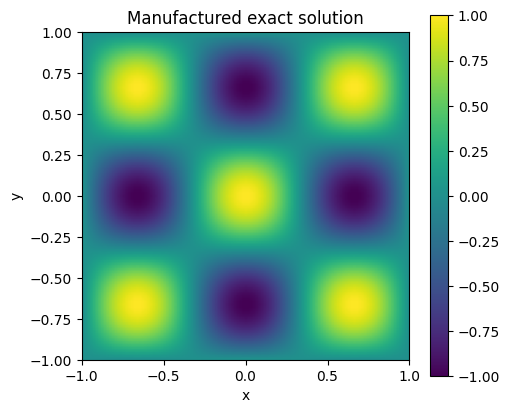

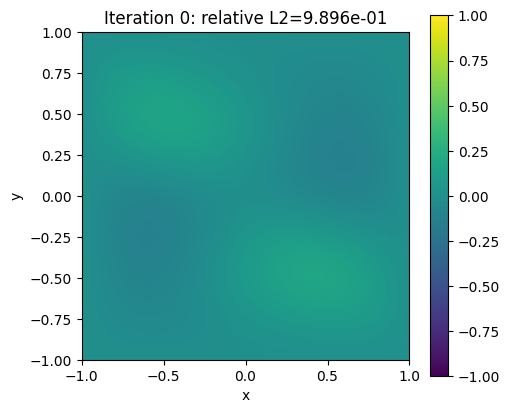

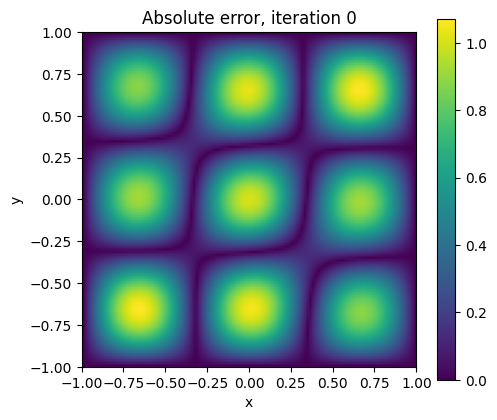

iteration=  0, F_lambda=-4.522522e-01, rel-L2=9.896e-01, rank=32, step=1.00e-02
iteration= 25, F_lambda=-1.499452e+01, rel-L2=4.192e-01, rank=49, step=2.50e-03


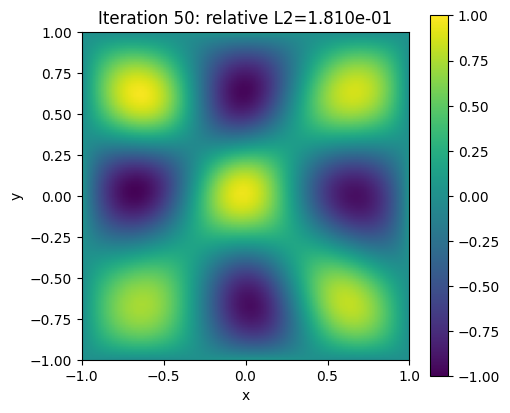

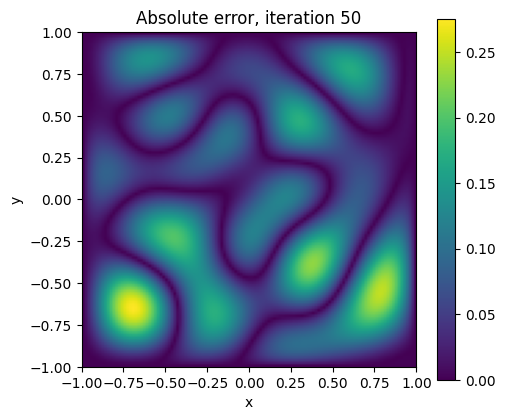

iteration= 50, F_lambda=-2.007925e+01, rel-L2=1.810e-01, rank=49, step=6.25e-04
iteration= 75, F_lambda=-2.039110e+01, rel-L2=1.668e-01, rank=49, step=2.50e-03


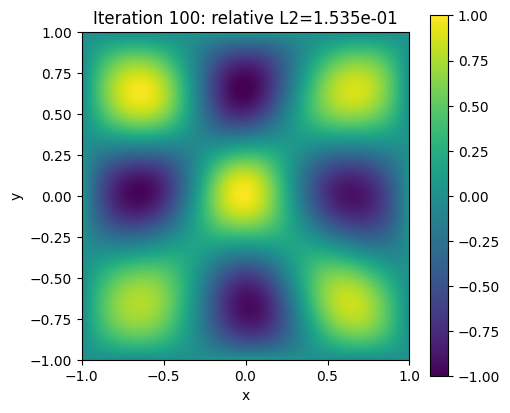

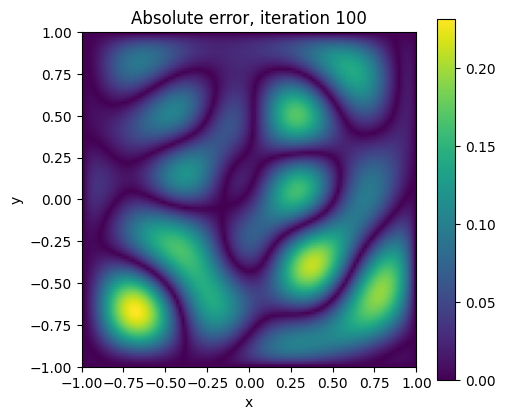

iteration=100, F_lambda=-2.062588e+01, rel-L2=1.535e-01, rank=49, step=2.50e-03
iteration=125, F_lambda=-2.075736e+01, rel-L2=1.452e-01, rank=48, step=2.50e-03
iteration=150, F_lambda=-2.085947e+01, rel-L2=1.384e-01, rank=48, step=2.50e-03
iteration=175, F_lambda=-2.094642e+01, rel-L2=1.325e-01, rank=48, step=2.50e-03


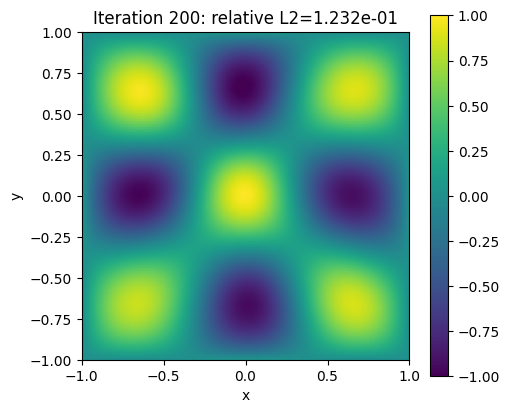

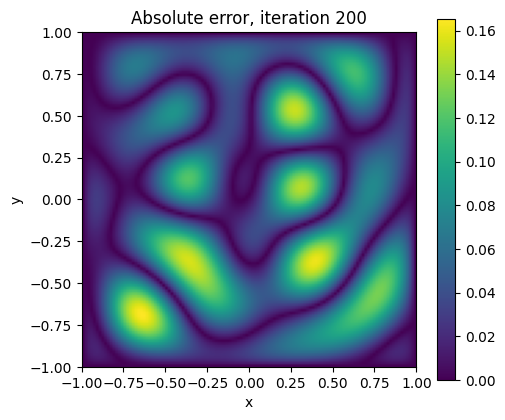

completed 200 outer updates in 51.8 seconds


In [7]:
# Save the exact field once for reference.
axis = torch.linspace(-1.0, 1.0, GRID_SIZE, device=DEVICE, dtype=DTYPE)
xx, yy = torch.meshgrid(axis, axis, indexing="ij")
plot_grid = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=1)
save_field_plot(
    exact_solution(plot_grid),
    "Manufactured exact solution",
    OUTPUT_DIR / "exact_solution.png",
    symmetric=True,
    limit=1.0,
)

history = {
    "iteration": [],
    "regularized_reduced_objective": [],
    "ritz_energy": [],
    "numerical_rank": [],
    "condition_estimate": [],
    "inner_residual": [],
    "outer_gradient_norm": [],
    "accepted_step": [],
    "monitor_iteration": [],
    "relative_l2": [],
}

start_time = time.time()
current_alpha = None

for iteration in range(OUTER_STEPS + 1):
    # Inner Ritz solve on the current tangent space.
    jacobian, spatial_jacobian = ritz_basis_matrices(theta, x_train)
    gram, load = assemble_ritz_system(jacobian, spatial_jacobian, f_train)
    alpha, diagnostics = solve_inner(gram, load)
    current_alpha = alpha

    ritz_energy = 0.5 * alpha @ gram @ alpha - load @ alpha
    reduced_objective = ritz_energy + 0.5 * RIDGE * (alpha @ alpha)

    history["iteration"].append(iteration)
    history["regularized_reduced_objective"].append(float(reduced_objective))
    history["ritz_energy"].append(float(ritz_energy))
    history["numerical_rank"].append(diagnostics["rank"])
    history["condition_estimate"].append(diagnostics["condition_estimate"])
    history["inner_residual"].append(diagnostics["relative_residual"])

    needs_monitor = iteration % MONITOR_EVERY == 0 or iteration in SNAPSHOT_STEPS
    rel_l2 = None
    if needs_monitor:
        rel_l2 = relative_l2_error(theta, alpha)
        history["monitor_iteration"].append(iteration)
        history["relative_l2"].append(rel_l2)

    if iteration in SNAPSHOT_STEPS:
        if rel_l2 is None:
            rel_l2 = relative_l2_error(theta, alpha)
        save_snapshot(iteration, theta, alpha, rel_l2)

    if iteration == OUTER_STEPS:
        history["outer_gradient_norm"].append(float("nan"))
        history["accepted_step"].append(float("nan"))
        break

    # Envelope derivative: alpha is held fixed; no differentiation through
    # the inner linear solve is performed.
    alpha_fixed = alpha.detach()
    fixed_alpha_energy = lambda th: direct_ritz_energy(th, alpha_fixed, x_train, f_train)
    energy_before = fixed_alpha_energy(theta)
    outer_gradient = grad(fixed_alpha_energy)(theta)
    gradient_norm = float(torch.linalg.norm(outer_gradient))

    # Armijo backtracking controls the strong curvature induced by the
    # second parameter derivative of T_theta.
    step = INITIAL_OUTER_STEP
    accepted = False
    for _ in range(MAX_BACKTRACKS):
        candidate = (theta - step * outer_gradient).detach()
        candidate_energy = float(fixed_alpha_energy(candidate))
        sufficient_decrease = (
            float(energy_before) - ARMIJO_C * step * gradient_norm**2
        )
        if candidate_energy <= sufficient_decrease:
            theta = candidate
            accepted = True
            break
        step *= BACKTRACK_FACTOR

    if not accepted:
        warnings.warn("Armijo search failed; this outer iteration was skipped.")
        step = 0.0
        theta = theta.detach()

    history["outer_gradient_norm"].append(gradient_norm)
    history["accepted_step"].append(step)

    if iteration % 25 == 0:
        monitor_text = "" if rel_l2 is None else f", rel-L2={rel_l2:.3e}"
        print(
            f"iteration={iteration:3d}, F_lambda={float(reduced_objective): .6e}"
            f"{monitor_text}, rank={diagnostics['rank']:2d}, step={step:.2e}"
        )

elapsed = time.time() - start_time
print(f"completed {OUTER_STEPS} outer updates in {elapsed:.1f} seconds")

## Convergence and saved artifacts

The regularized reduced objective is the value of the inner stabilized problem. The relative \(L^2\) error is measured on an independent Sobol cloud. Field PNGs and reloadable `.pt` states were written at iterations 0, 50, 100, and 200.

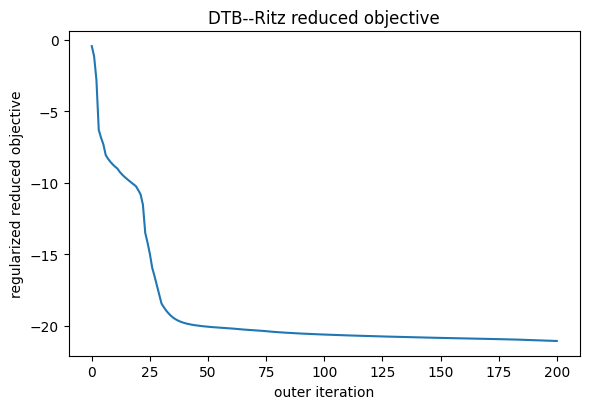

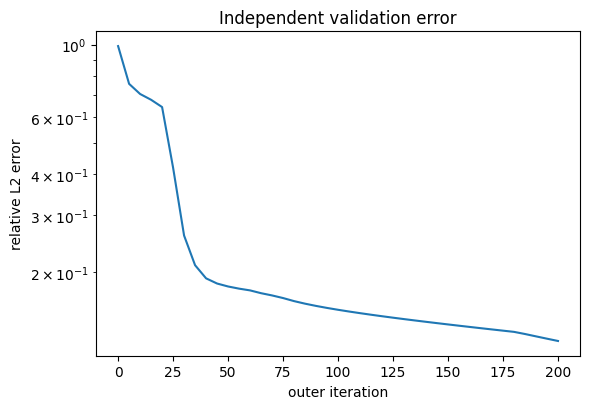

{
  "initial_relative_l2": 0.9896155854520073,
  "final_relative_l2": 0.12316325092254869,
  "initial_reduced_objective": -0.4522521900279094,
  "final_reduced_objective": -21.074386720574537,
  "elapsed_seconds": 51.830198764801025,
  "parameter_count": 85,
  "using_repository_dtb": false
}

Saved files:
 - dtb_ritz_outputs/convergence_objective.png
 - dtb_ritz_outputs/convergence_relative_l2.png
 - dtb_ritz_outputs/error_iter_000.png
 - dtb_ritz_outputs/error_iter_050.png
 - dtb_ritz_outputs/error_iter_100.png
 - dtb_ritz_outputs/error_iter_200.png
 - dtb_ritz_outputs/exact_solution.png
 - dtb_ritz_outputs/history.json
 - dtb_ritz_outputs/metrics.json
 - dtb_ritz_outputs/solution_iter_000.png
 - dtb_ritz_outputs/solution_iter_050.png
 - dtb_ritz_outputs/solution_iter_100.png
 - dtb_ritz_outputs/solution_iter_200.png
 - dtb_ritz_outputs/state_iter_000.pt
 - dtb_ritz_outputs/state_iter_050.pt
 - dtb_ritz_outputs/state_iter_100.pt
 - dtb_ritz_outputs/state_iter_200.pt


In [8]:
iterations = np.asarray(history["iteration"])
reduced_values = np.asarray(history["regularized_reduced_objective"])
monitor_iterations = np.asarray(history["monitor_iteration"])
relative_errors = np.asarray(history["relative_l2"])

plt.figure(figsize=(6.0, 4.2))
plt.plot(iterations, reduced_values)
plt.xlabel("outer iteration")
plt.ylabel("regularized reduced objective")
plt.title("DTB--Ritz reduced objective")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "convergence_objective.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(6.0, 4.2))
plt.semilogy(monitor_iterations, relative_errors)
plt.xlabel("outer iteration")
plt.ylabel("relative L2 error")
plt.title("Independent validation error")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "convergence_relative_l2.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

summary = {
    "initial_relative_l2": float(relative_errors[0]),
    "final_relative_l2": float(relative_errors[-1]),
    "initial_reduced_objective": float(reduced_values[0]),
    "final_reduced_objective": float(reduced_values[-1]),
    "elapsed_seconds": elapsed,
    "parameter_count": parameter_count,
    "using_repository_dtb": USING_REPOSITORY_DTB,
}

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)
with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as handle:
    json.dump(history, handle, indent=2)

print(json.dumps(summary, indent=2))
print("\nSaved files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)

## Implementation notes

- **No refitting:** the stationary algorithm updates the base point \(\theta\) directly. The time-dependent DTB reset mechanism is not used.
- **Fixed samples:** the inner solve and the corresponding outer derivative use the same cloud. The independent cloud is diagnostic only.
- **Stabilization:** `RIDGE > 0` gives a unique, smooth inner coefficient vector and makes the demonstration robust. Setting it to zero switches to a truncated pseudoinverse and recovers the unregularized inner formulation.
- **Scaling up:** for a much larger network, adapt the restricted-coordinate construction in `DTB_rep/dtb.py` and keep a selected tangent basis fixed over a block of outer iterations.